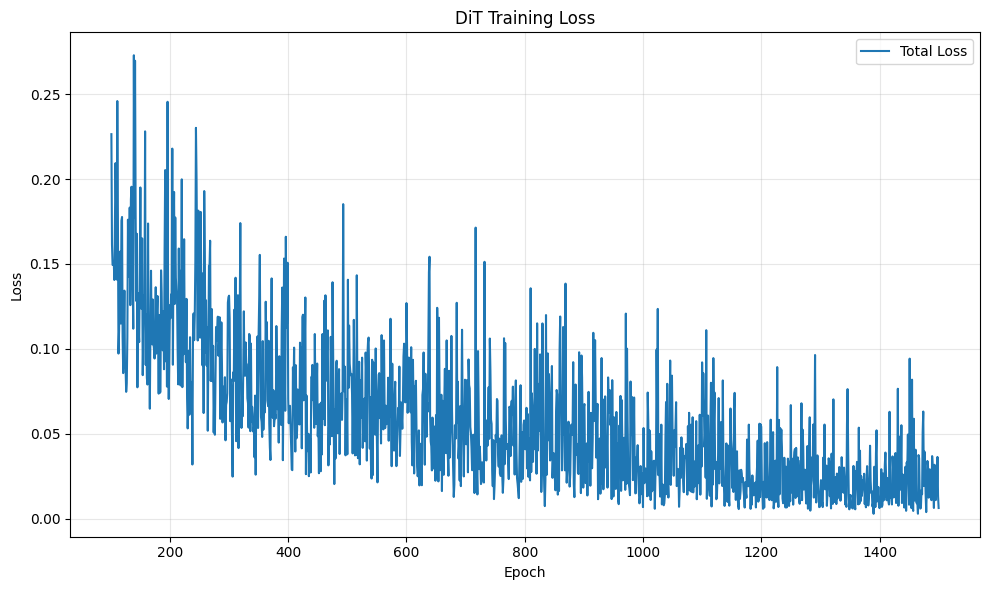

In [2]:
import re
import matplotlib.pyplot as plt

file_path = "2_1500_0_losses.txt"

epochs = []
total_loss = []
data_loss = []
bc_loss = []

with open(file_path, "r") as f:
    for line in f:
        
        total_loss.append(float(line.split("loss=")[-1]))

plt.figure(figsize=(10, 6))

epochs = range(1, len(total_loss) + 1)
plt.plot(epochs[100:], total_loss[100:], label="Total Loss")


plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DiT Training Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# plt.savefig("training_losses.png", dpi=300)
plt.show()

In [41]:
n = 2
k = 1

r = list(range(10))

valid_diff = {}

i = 0
while i + k <= 9:
    valid_diff[str(r[i])] = str(r[i+k])
    valid_diff[str(r[i+k])] = str(r[i])
    i += 1

valid_diff

{'0': '1',
 '1': '2',
 '2': '3',
 '3': '4',
 '4': '5',
 '5': '6',
 '6': '7',
 '7': '8',
 '8': '9',
 '9': '8'}

In [42]:
def recusion(s, t):

    if (len(s) == n):
        if s[0] == "0": 
            return
        print(s)
        return

    for v in valid_diff[t]:
        recusion(s + v, v)

for k, _ in valid_diff.items():
    # if k == "0": continue
    recusion("", k)

12
23
34
45
56
67
78
89
98
89


In [10]:
memo = {}
def recusion(s, open_count, close_count):
    if close_count < open_count:
        return False
     
    if (open_count == 0) and (close_count == 0):
        print(s)
        return True
    
    if (s, open_count, close_count) in memo:
        return memo[(s, open_count, close_count)]

    if not s:
        s = "("

    if open_count:
        recusion(s + "(", open_count - 1, close_count)
    if close_count:
        recusion(s + ")", open_count, close_count - 1)

    memo[(s, open_count, close_count)] = s

recusion("", 0, 1)

()


In [ ]:
memo

{('((())', 0, 1): '((())',
 ('((()', 0, 2): '((()',
 ('(((', 0, 3): '(((',
 ('(()()', 0, 1): '(()()',
 ('(()(', 0, 2): '(()(',
 ('(())(', 0, 1): '(())(',
 ('(())', 1, 1): '(())',
 ('(()', 1, 2): '(()',
 ('((', 1, 3): '((',
 ('()(()', 0, 1): '()(()',
 ('()((', 0, 2): '()((',
 ('()()(', 0, 1): '()()(',
 ('()()', 1, 1): '()()',
 ('()(', 1, 2): '()(',
 ('()', 2, 2): '()',
 ('(', 2, 3): '('}

In [5]:
import torch
rec    = torch.rand(5, 4, 32, 32)
tgt    = torch.rand(5, 4, 32, 32)
mask   = torch.rand(5, 32, 32)


m = mask.float().unsqueeze(1)                              # [B,1,H,W]
m.shape

torch.Size([5, 1, 32, 32])

In [6]:
n = m.sum((2, 3)).clamp(min=1)                             # [B,1]
n.shape

torch.Size([5, 1])

In [7]:
mean = (tgt * m).sum((2, 3)) / n                           # [B,C]
mean.shape

torch.Size([5, 4])

In [23]:
var = (((tgt - mean[..., None, None]) ** 2) * m).sum((2, 3)) / n
var.shape

torch.Size([5, 4])

In [31]:
m[..., 1:].shape

torch.Size([5, 1, 32, 31])